In [1]:
import pandas as pd
import scanpy as sc
import plotnine as p9

import liana as li
import cell2cell as c2c
import decoupler as dc # needed for pathway enrichment

import warnings
warnings.filterwarnings('ignore')
from collections import defaultdict

%matplotlib inline

In [2]:
# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3             
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

scanpy==1.9.6 anndata==0.10.4 umap==0.5.3 numpy==1.23.4 scipy==1.9.1 pandas==2.1.4 scikit-learn==1.2.0 statsmodels==0.14.1 igraph==0.10.8 pynndescent==0.5.8


## 1. Load & Prep Data

### 1.1 Download Data
```bash
# download data (GSE174188) using the following bash commands:
raw_data_dir=/home/qdai8/projects/Projects/STDCC/Data/RDA/SLE/raw
mkdir -p ${raw_data_dir}
cd ${raw_data_dir}
wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE174nnn/GSE174188/suppl/GSE174188_CLUES1_adjusted.h5ad.gz
# unzip 
gzip -d GSE174188_CLUES1_adjusted.h5ad.gz
```

### 1.2 Showcase anndata object

In [4]:
# read in SLE data in h5ad 
# it needs ~25G memory and several minutes
data_dir = '/home/qdai8/projects/Projects/STDCC/Data/RDA/SLE/'
SLE_data_path = data_dir + 'raw/GSE174188_CLUES1_adjusted.h5ad'
data = sc.read_h5ad(SLE_data_path)

In [5]:
data

AnnData object with n_obs × n_vars = 1263676 × 1999
    obs: 'batch_cov', 'ind_cov', 'Processing_Cohort', 'louvain', 'cg_cov', 'ct_cov', 'L3', 'ind_cov_batch_cov', 'Age', 'Sex', 'pop_cov', 'Status', 'SLE_status'
    var: 'gene_ids'
    uns: 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

The data was cleaned, batch corrected, clustered, and annotated as described in the dataset's original publication: https://www.science.org/doi/10.1126/science.abf1970?url_ver=Z39.88-2003&rfr_id=ori:rid:crossref.org&rfr_dat=cr_pub%20%200pubmed. 
We extracted the raw counts and the annotations to use in the following analysis.

In [6]:
import anndata as ad
# get the raw counts 
raw_data = ad.AnnData(data.raw.X)

In [7]:
print(raw_data)

AnnData object with n_obs × n_vars = 1263676 × 32738


In [8]:
raw_data.obs = data.obs[['ind_cov', 'batch_cov', 'ind_cov_batch_cov', 'Processing_Cohort', 
                         'Age', 'Sex', 'pop_cov', 'SLE_status',
                         'cg_cov']]

In [9]:
raw_data.var = data.raw.var

### 1.4 Basic QC

In [10]:
# filter cells and genes
sc.pp.filter_cells(raw_data, min_genes=200)
sc.pp.filter_genes(raw_data, min_cells=3)
# log1p normalize the data
sc.pp.normalize_total(raw_data)
sc.pp.log1p(raw_data)

filtered out 196 cells that have less than 200 genes expressed
filtered out 7022 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:08)


In [11]:
raw_data.X.min()

0.0

In [12]:
raw_data.X.max()

7.192308

### 1.5 Select Highly Variable Genes

In [13]:
sc.pp.highly_variable_genes(raw_data, n_top_genes=2000, flavor='seurat')

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:20)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


### 1.6 Check Batch Effect using UMAP

In [14]:
sc.tl.pca(raw_data)

computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:40)


In [15]:
sc.pp.neighbors(raw_data)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:06:37)


In [16]:
print(raw_data)

AnnData object with n_obs × n_vars = 1263480 × 25716
    obs: 'ind_cov', 'batch_cov', 'ind_cov_batch_cov', 'Processing_Cohort', 'Age', 'Sex', 'pop_cov', 'SLE_status', 'cg_cov', 'n_genes'
    var: 'gene_ids', 'feature_types-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


In [17]:
sc.tl.umap(raw_data)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (1:13:06)


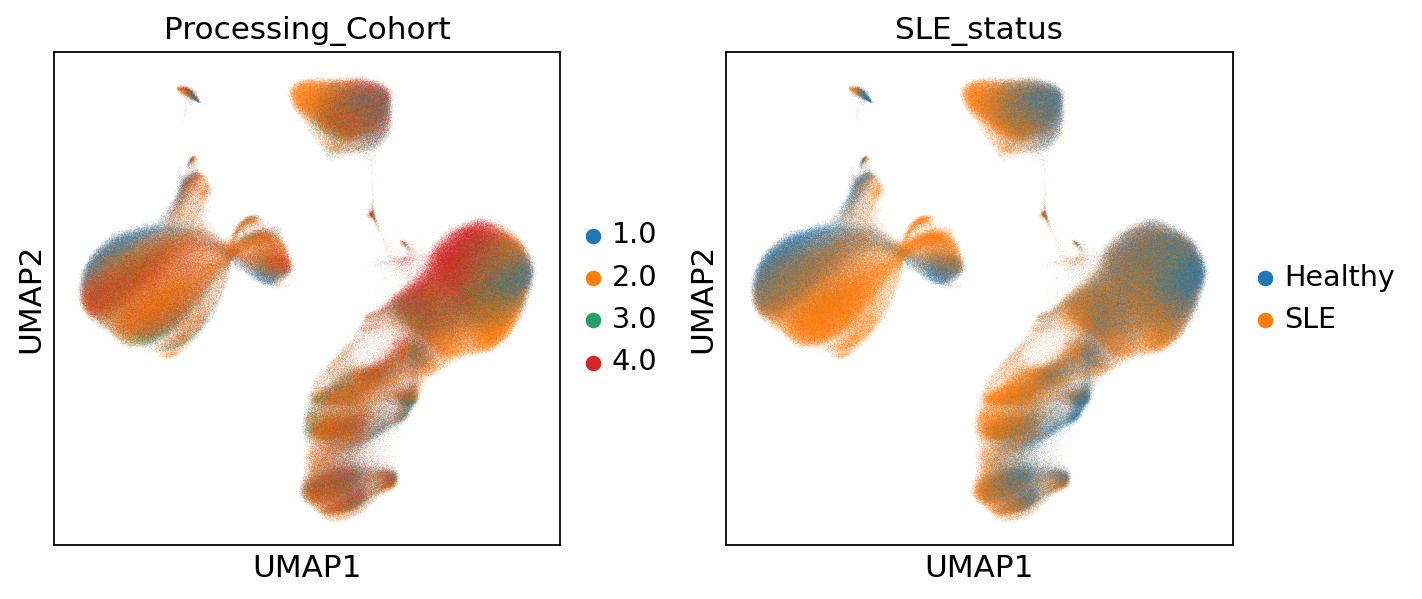

In [18]:
sc.pl.umap(raw_data, color=['Processing_Cohort', 'SLE_status'])

In [19]:
import os
out_dir = data_dir + 'processed'
# Create the directory if it does not exist
os.makedirs(out_dir, exist_ok=True)

# Now you can save your data in this directory
raw_data.write(os.path.join(out_dir, 'GSE174188_basic_processed.h5ad'))

- Save disease status and ancestry for the sample with most number of cell per subject

In [ ]:
# Step 1: Extract the obs DataFrame
obs_df = raw_data.obs
# Step 2: Group by 'ind_cov' and 'batch_cov' and count the number of cells in each group
cell_counts = obs_df.groupby(['ind_cov', 'batch_cov']).size().reset_index(name='num_cells')
# Step 3: Identify the sample with the most cells for each subject
idx = cell_counts.groupby('ind_cov')['num_cells'].idxmax()
max_samples_per_subject = cell_counts.loc[idx]

# Step 4: Filter the original AnnData object based on the selected samples
# First, create a boolean mask for the cells to keep
subject_sample_pairs = max_samples_per_subject.set_index(['ind_cov', 'batch_cov']).index
mask = raw_data.obs.set_index(['ind_cov', 'batch_cov']).index.isin(subject_sample_pairs)

# Apply the mask to filter the AnnData object
filtered_adata = raw_data[mask].copy()

out_cols = ['ind_cov', 'Status']
subject_info = filtered_adata.obs[out_cols].drop_duplicates().reset_index(drop=True)

subject_info.to_csv(out_dir +'subjects_status.txt', 
                    mode='w',
                    index=None,
                    header=True,
                    sep='\t')
